<a href="https://colab.research.google.com/github/Aakanksha-6/Data-Science-internship-projects/blob/OCD-Patient-Dataset_-Demographics-%26-Clinical-Data/4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/OCD Patient Dataset_ Demographics & Clinical Data.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Patient ID,Age,Gender,Ethnicity,Marital Status,Education Level,OCD Diagnosis Date,Duration of Symptoms (months),Previous Diagnoses,Family History of OCD,Obsession Type,Compulsion Type,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions),Depression Diagnosis,Anxiety Diagnosis,Medications
0,1018,32,Female,African,Single,Some College,2016-07-15,203,MDD,No,Harm-related,Checking,17,10,Yes,Yes,SNRI
1,2406,69,Male,African,Divorced,Some College,2017-04-28,180,NaN,Yes,Harm-related,Washing,21,25,Yes,Yes,SSRI
2,1188,57,Male,Hispanic,Divorced,College Degree,2018-02-02,173,MDD,No,Contamination,Checking,3,4,No,No,Benzodiazepine
3,6200,27,Female,Hispanic,Married,College Degree,2014-08-25,126,PTSD,Yes,Symmetry,Washing,14,28,Yes,Yes,SSRI
4,5824,56,Female,Hispanic,Married,High School,2022-02-20,168,PTSD,Yes,Hoarding,Ordering,39,18,No,No,NaN


In [ ]:
# Fill missing values in 'Previous Diagnoses' with 'Unknown'
df['Previous Diagnoses'] = df['Previous Diagnoses'].fillna('Unknown')

# Fill missing values in 'Medications' with 'Unknown'
df['Medications'] = df['Medications'].fillna('Unknown')

# Verify that missing values have been handled
print(df.isnull().sum())

Patient ID                       0
Age                              0
Gender                           0
Ethnicity                        0
Marital Status                   0
Education Level                  0
OCD Diagnosis Date               0
Duration of Symptoms (months)    0
Previous Diagnoses               0
Family History of OCD            0
Obsession Type                   0
Compulsion Type                  0
Y-BOCS Score (Obsessions)        0
Y-BOCS Score (Compulsions)       0
Depression Diagnosis             0
Anxiety Diagnosis                0
Medications                      0
dtype: int64


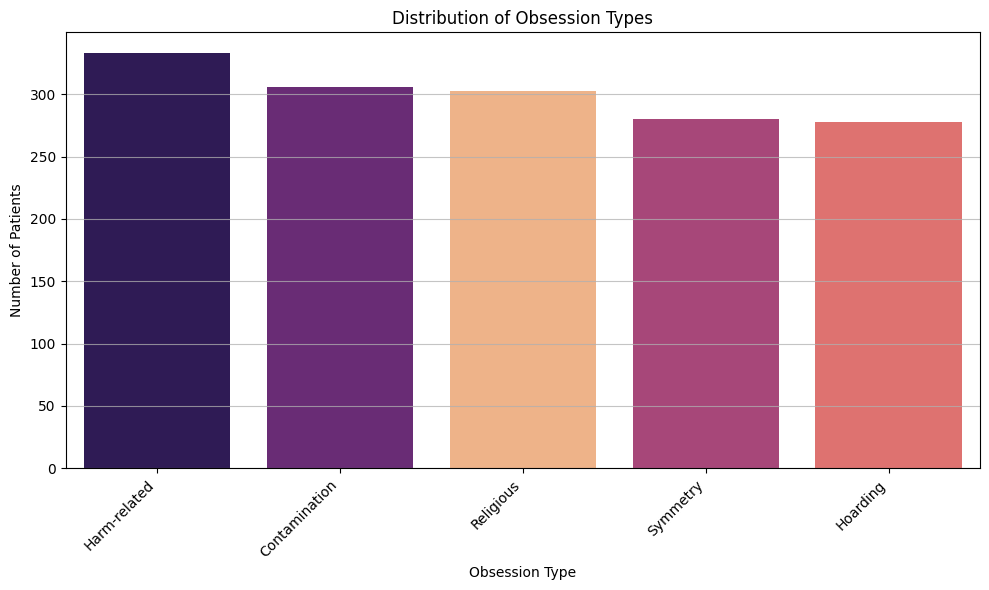

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Obsession Type', order=df['Obsession Type'].value_counts().index, palette='magma', hue='Obsession Type', legend=False)
plt.title('Distribution of Obsession Types')
plt.xlabel('Obsession Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

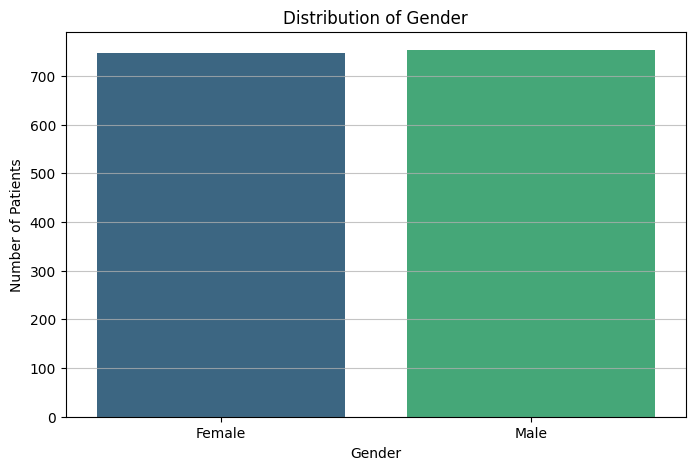

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Gender', hue='Gender', palette='viridis', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.grid(axis='y', alpha=0.75)
plt.show()

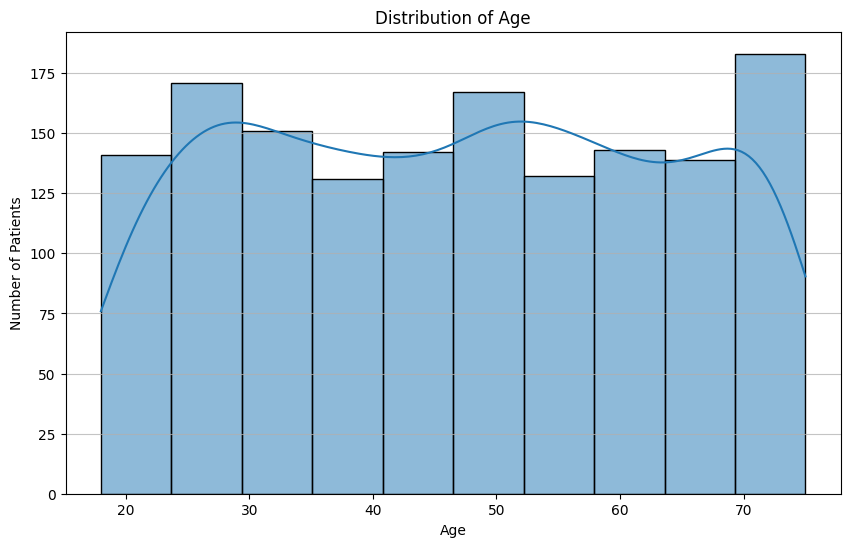

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=10, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
print(df.info())
print(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Patient ID                     1500 non-null   int64 
 1   Age                            1500 non-null   int64 
 2   Gender                         1500 non-null   object
 3   Ethnicity                      1500 non-null   object
 4   Marital Status                 1500 non-null   object
 5   Education Level                1500 non-null   object
 6   OCD Diagnosis Date             1500 non-null   object
 7   Duration of Symptoms (months)  1500 non-null   int64 
 8   Previous Diagnoses             1252 non-null   object
 9   Family History of OCD          1500 non-null   object
 10  Obsession Type                 1500 non-null   object
 11  Compulsion Type                1500 non-null   object
 12  Y-BOCS Score (Obsessions)      1500 non-null   int64 
 13  Y-B

In [ ]:
# Create 'Severity' feature
df['Severity'] = df['Y-BOCS Score (Obsessions)'] + df['Y-BOCS Score (Compulsions)']

# Create 'Age_Group' feature
df['Age_Group'] = pd.cut(df['Age'], bins=[0,25,40,60,100], labels=['Young','Adult','Mid','Senior'], right=False)

# Display the first few rows with the new features and their info to verify
display(df[['Age', 'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)', 'Severity', 'Age_Group']].head())
print(df[['Severity', 'Age_Group']].info())

,Age,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions),Severity,Age_Group
0,32,17,10,27,Adult
1,69,21,25,46,Senior
2,57,3,4,7,Mid
3,27,14,28,42,Adult
4,56,39,18,57,Mid


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Severity   1500 non-null   int64   
 1   Age_Group  1500 non-null   category
dtypes: category(1), int64(1)
memory usage: 13.5 KB
None


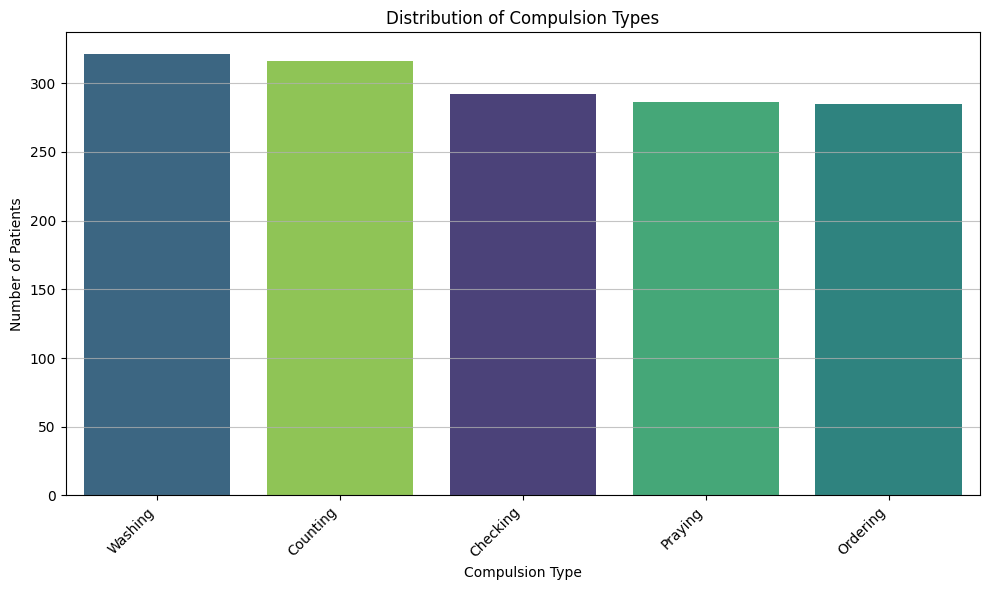

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Compulsion Type', order=df['Compulsion Type'].value_counts().index, palette='viridis', hue='Compulsion Type', legend=False)
plt.title('Distribution of Compulsion Types')
plt.xlabel('Compulsion Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

In [ ]:
print('Correlation Analysis:')

# Correlation between Duration of Symptoms and Severity
duration_severity_corr = df['Duration of Symptoms (months)'].corr(df['Severity'])
print(f"Correlation between Duration of Symptoms and Severity: {duration_severity_corr:.2f}")

# Correlation between Y-BOCS Obsessions and Compulsions scores
obs_comp_corr = df['Y-BOCS Score (Obsessions)'].corr(df['Y-BOCS Score (Compulsions)'])
print(f"Correlation between Y-BOCS Score (Obsessions) and Y-BOCS Score (Compulsions): {obs_comp_corr:.2f}")

Correlation Analysis:
Correlation between Duration of Symptoms and Severity: 0.03
Correlation between Y-BOCS Score (Obsessions) and Y-BOCS Score (Compulsions): 0.03


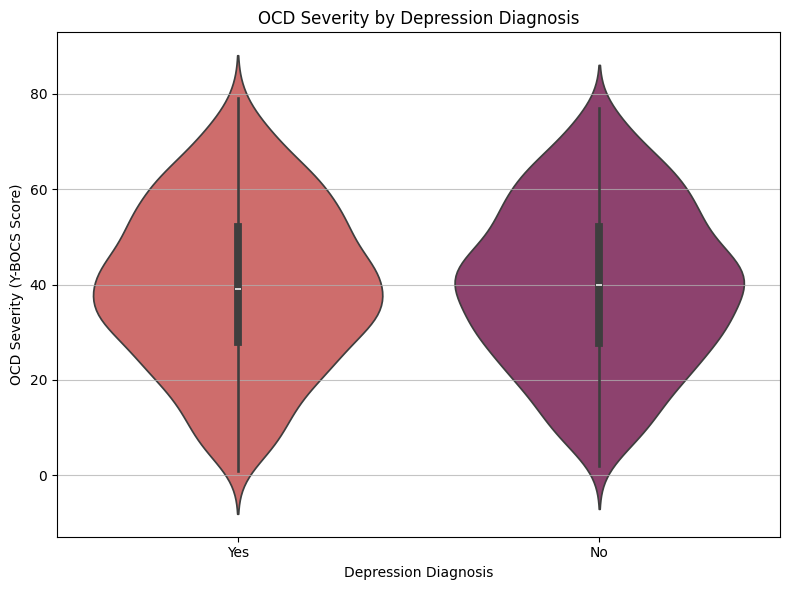

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='Depression Diagnosis', y='Severity', palette='flare', hue='Depression Diagnosis', legend=False)
plt.title('OCD Severity by Depression Diagnosis')
plt.xlabel('Depression Diagnosis')
plt.ylabel('OCD Severity (Y-BOCS Score)')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

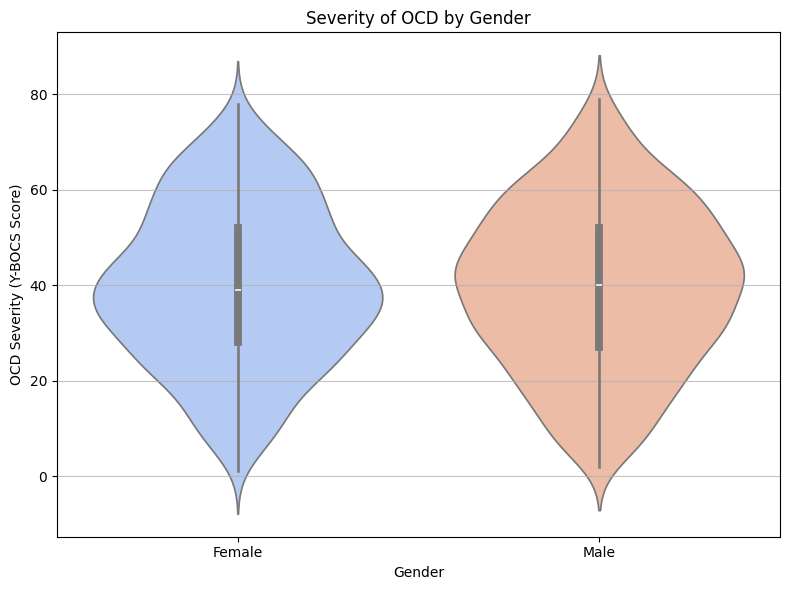

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='Gender', y='Severity', palette='coolwarm', hue='Gender', legend=False)
plt.title('Severity of OCD by Gender')
plt.xlabel('Gender')
plt.ylabel('OCD Severity (Y-BOCS Score)')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

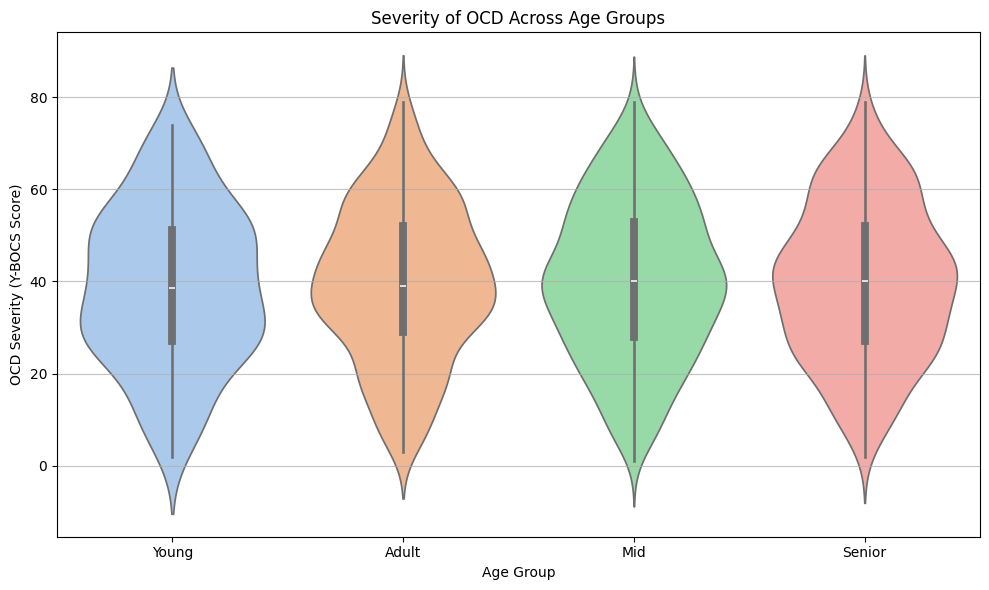

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Age_Group', y='Severity', palette='pastel', hue='Age_Group', legend=False)
plt.title('Severity of OCD Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('OCD Severity (Y-BOCS Score)')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

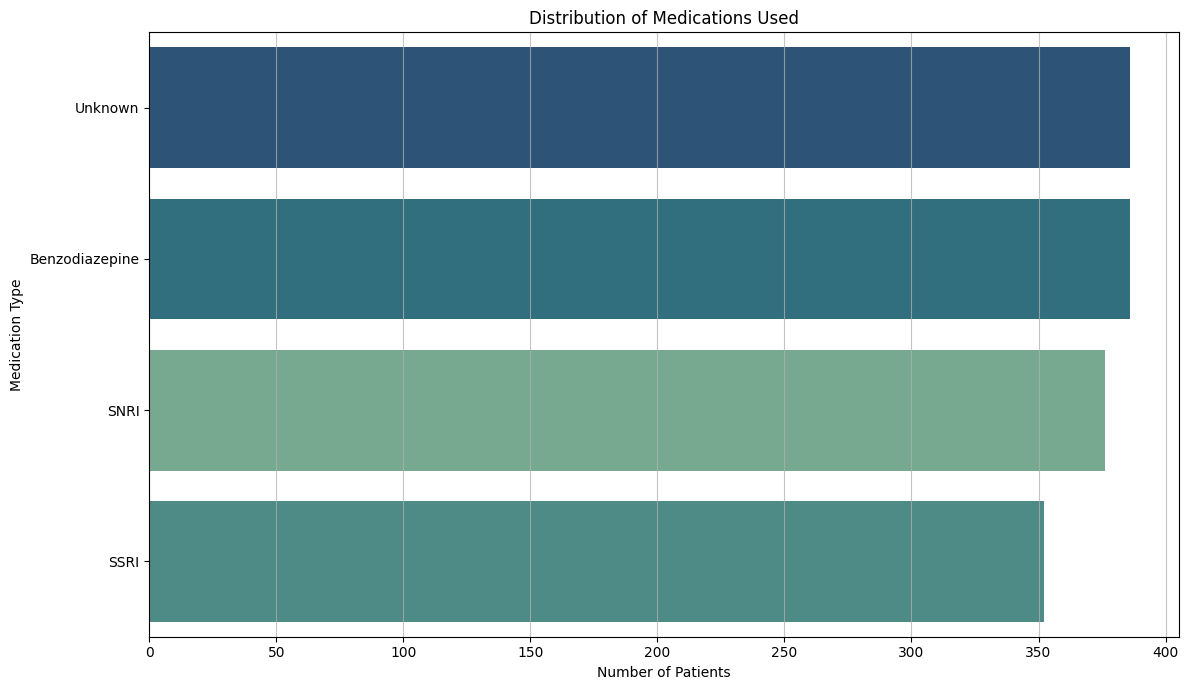

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.countplot(data=df, y='Medications', order=df['Medications'].value_counts().index, palette='crest', hue='Medications', legend=False)
plt.title('Distribution of Medications Used')
plt.xlabel('Number of Patients')
plt.ylabel('Medication Type')
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

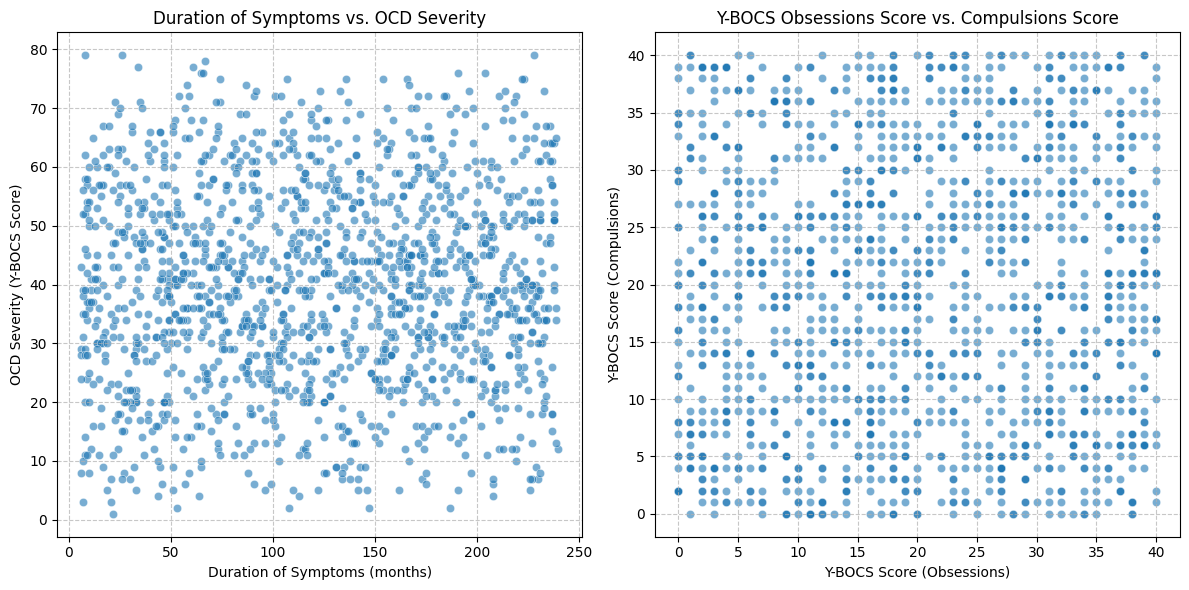

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot for Duration vs Severity
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Duration of Symptoms (months)', y='Severity', alpha=0.6)
plt.title('Duration of Symptoms vs. OCD Severity')
plt.xlabel('Duration of Symptoms (months)')
plt.ylabel('OCD Severity (Y-BOCS Score)')
plt.grid(True, linestyle='--', alpha=0.7)

# Scatter plot for Obsessions vs Compulsions scores
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Y-BOCS Score (Obsessions)', y='Y-BOCS Score (Compulsions)', alpha=0.6)
plt.title('Y-BOCS Obsessions Score vs. Compulsions Score')
plt.xlabel('Y-BOCS Score (Obsessions)')
plt.ylabel('Y-BOCS Score (Compulsions)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
X = df.drop(columns=['Patient ID', 'OCD Diagnosis Date', 'Depression Diagnosis', 'Severity'])
y = df['Depression Diagnosis']

# Identify categorical and numerical features
# Re-evaluating features, considering original 'Y-BOCS Score (Obsessions)' and 'Y-BOCS Score (Compulsions)'
categorical_features = X.select_dtypes(include=['object', 'category']).columns # FIX: Include 'category' dtype
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Preprocessing pipeline for categorical features (One-Hot Encoding)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Original features: {X.columns.tolist()}\n")
print(f"Categorical features: {categorical_features.tolist()}\n")
print(f"Numerical features: {numerical_features.tolist()}\n")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Original features: ['Age', 'Gender', 'Ethnicity', 'Marital Status', 'Education Level', 'Duration of Symptoms (months)', 'Previous Diagnoses', 'Family History of OCD', 'Obsession Type', 'Compulsion Type', 'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)', 'Anxiety Diagnosis', 'Medications', 'Age_Group']

Categorical features: ['Gender', 'Ethnicity', 'Marital Status', 'Education Level', 'Previous Diagnoses', 'Family History of OCD', 'Obsession Type', 'Compulsion Type', 'Anxiety Diagnosis', 'Medications', 'Age_Group']

Numerical features: ['Age', 'Duration of Symptoms (months)', 'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)']

Shape of X_train: (1050, 15)
Shape of X_test: (450, 15)
Shape of y_train: (1050,)
Shape of y_test: (450,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Logistic Regression Model ---
print("\n--- Logistic Regression Model ---")
log_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('classifier', LogisticRegression(solver='liblinear', random_state=42))])

log_reg_pipeline.fit(X_train, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test)

print(f"Accuracy (Logistic Regression): {accuracy_score(y_test, y_pred_lr):.2f}")
print("Classification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix (Logistic Regression):")
print(confusion_matrix(y_test, y_pred_lr))

# --- Random Forest Classifier ---
print("\n--- Random Forest Classifier ---")
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', RandomForestClassifier(random_state=42))])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print(f"Accuracy (Random Forest): {accuracy_score(y_test, y_pred_rf):.2f}")
print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))


--- Logistic Regression Model ---
Accuracy (Logistic Regression): 0.54
Classification Report (Logistic Regression):
              precision    recall  f1-score   support

          No       0.52      0.45      0.49       218
         Yes       0.54      0.61      0.58       232

    accuracy                           0.54       450
   macro avg       0.53      0.53      0.53       450
weighted avg       0.53      0.54      0.53       450

Confusion Matrix (Logistic Regression):
[[ 99 119]
 [ 90 142]]

--- Random Forest Classifier ---
Accuracy (Random Forest): 0.49
Classification Report (Random Forest):
              precision    recall  f1-score   support

          No       0.47      0.43      0.45       218
         Yes       0.51      0.56      0.53       232

    accuracy                           0.49       450
   macro avg       0.49      0.49      0.49       450
weighted avg       0.49      0.49      0.49       450

Confusion Matrix (Random Forest):
[[ 93 125]
 [103 129]]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
X = df.drop(columns=['Patient ID', 'OCD Diagnosis Date', 'Depression Diagnosis', 'Severity'])
y = df['Depression Diagnosis']

# Identify categorical and numerical features
# Re-evaluating features, considering original 'Y-BOCS Score (Obsessions)' and 'Y-BOCS Score (Compulsions)'
categorical_features = X.select_dtypes(include=['object', 'category']).columns # FIX: Include 'category' dtype
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Preprocessing pipeline for categorical features (One-Hot Encoding)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Original features: {X.columns.tolist()}\n")
print(f"Categorical features: {categorical_features.tolist()}\n")
print(f"Numerical features: {numerical_features.tolist()}\n")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Original features: ['Age', 'Gender', 'Ethnicity', 'Marital Status', 'Education Level', 'Duration of Symptoms (months)', 'Previous Diagnoses', 'Family History of OCD', 'Obsession Type', 'Compulsion Type', 'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)', 'Anxiety Diagnosis', 'Medications', 'Age_Group']

Categorical features: ['Gender', 'Ethnicity', 'Marital Status', 'Education Level', 'Previous Diagnoses', 'Family History of OCD', 'Obsession Type', 'Compulsion Type', 'Anxiety Diagnosis', 'Medications', 'Age_Group']

Numerical features: ['Age', 'Duration of Symptoms (months)', 'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)']

Shape of X_train: (1050, 15)
Shape of X_test: (450, 15)
Shape of y_train: (1050,)
Shape of y_test: (450,)


### Implementing and Evaluating XGBoost Model

Given the relatively low performance of the Logistic Regression and Random Forest models, we will now implement an XGBoost Classifier. XGBoost (Extreme Gradient Boosting) is a powerful and efficient open-source library that provides a gradient boosting framework for C++, Python, R, Java, and other languages. It is known for its high performance and speed.

We will use the same preprocessed data (`X_train`, `X_test`, `y_train`, `y_test`) and `preprocessor` pipeline defined previously to maintain consistency and allow for a direct comparison of model performance.

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

print("\n--- XGBoost Classifier ---")

# Encode target variable y to numerical labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))])

xgb_pipeline.fit(X_train, y_train_encoded) # Fit with encoded labels
y_pred_xgb = xgb_pipeline.predict(X_test)

# Decode predictions back for classification report or keep encoded for consistency based on model output
# For classification_report, we can use the original y_test and y_pred_xgb will be 0s and 1s, which report can handle
print(f"Accuracy (XGBoost): {accuracy_score(y_test_encoded, y_pred_xgb):.2f}") # Compare with encoded y_test
print("Classification Report (XGBoost):")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_))
print("Confusion Matrix (XGBoost):")
print(confusion_matrix(y_test_encoded, y_pred_xgb))


--- XGBoost Classifier ---
Accuracy (XGBoost): 0.50
Classification Report (XGBoost):
              precision    recall  f1-score   support

          No       0.49      0.51      0.50       218
         Yes       0.52      0.50      0.51       232

    accuracy                           0.50       450
   macro avg       0.50      0.50      0.50       450
weighted avg       0.51      0.50      0.50       450

Confusion Matrix (XGBoost):
[[111 107]
 [116 116]]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:38:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Comparative Analysis of Model Performance

Now that we have evaluated three different models (Logistic Regression, Random Forest, and XGBoost), let's compare their performance to draw a more informed conclusion about predicting 'Depression Diagnosis' from our dataset. We'll focus on accuracy, precision, recall, and F1-score to understand the strengths and weaknesses of each model.

### Shifting ML Task: Predicting OCD Severity (Regression)

The original objective mentioned predicting the severity of OCD. Currently, our models predict 'Depression Diagnosis' (a classification task). To address the severity prediction, we will now build a regression model with `Severity` as the target variable.

This involves:
1.  **Redefining the target variable `y`** to be the `Severity` column.
2.  **Splitting the data** into training and testing sets.
3.  **Implementing and evaluating** regression models (e.g., RandomForestRegressor, XGBoostRegressor).

Let's start by preparing the data for this new regression task.

In [ ]:
# Redefine features (X) and target (y) for Severity prediction (Regression)
# Exclude 'Y-BOCS Score (Obsessions)' and 'Y-BOCS Score (Compulsions)' from features to avoid data leakage
X_severity = df.drop(columns=['Patient ID', 'OCD Diagnosis Date', 'Depression Diagnosis', 'Severity', 'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)'])
y_severity = df['Severity']

# Identify categorical and numerical features
categorical_features_severity = X_severity.select_dtypes(include=['object', 'category']).columns
numerical_features_severity = X_severity.select_dtypes(include=['int64', 'float64']).columns

# Preprocessing pipeline for categorical features (One-Hot Encoding)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor_severity = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_severity)
    ],
    remainder='passthrough' # Keep numerical features as they are
)

# Split data into training and testing sets
X_train_severity, X_test_severity, y_train_severity, y_test_severity = train_test_split(
    X_severity, y_severity, test_size=0.3, random_state=42
)

print(f"Original features for Severity prediction: {X_severity.columns.tolist()}\n")
print(f"Categorical features for Severity prediction: {categorical_features_severity.tolist()}\n")
print(f"Numerical features for Severity prediction: {numerical_features_severity.tolist()}\n")
print(f"Shape of X_train_severity: {X_train_severity.shape}")
print(f"Shape of X_test_severity: {X_test_severity.shape}")
print(f"Shape of y_train_severity: {y_train_severity.shape}")
print(f"Shape of y_test_severity: {y_test_severity.shape}")

Original features for Severity prediction: ['Age', 'Gender', 'Ethnicity', 'Marital Status', 'Education Level', 'Duration of Symptoms (months)', 'Previous Diagnoses', 'Family History of OCD', 'Obsession Type', 'Compulsion Type', 'Anxiety Diagnosis', 'Medications', 'Age_Group']

Categorical features for Severity prediction: ['Gender', 'Ethnicity', 'Marital Status', 'Education Level', 'Previous Diagnoses', 'Family History of OCD', 'Obsession Type', 'Compulsion Type', 'Anxiety Diagnosis', 'Medications', 'Age_Group']

Numerical features for Severity prediction: ['Age', 'Duration of Symptoms (months)']

Shape of X_train_severity: (1050, 13)
Shape of X_test_severity: (450, 13)
Shape of y_train_severity: (1050,)
Shape of y_test_severity: (450,)


### Implementing and Evaluating Regression Models

Now that the data is prepared, let's implement and evaluate a few regression models to predict `Severity`. We'll use metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) to assess their performance.

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# --- Linear Regression Model ---
print("\n--- Linear Regression Model ---")
lin_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor_severity),
                                   ('regressor', LinearRegression())])

lin_reg_pipeline.fit(X_train_severity, y_train_severity)
y_pred_lr_severity = lin_reg_pipeline.predict(X_test_severity)

print(f"MAE (Linear Regression): {mean_absolute_error(y_test_severity, y_pred_lr_severity):.2f}")
print(f"MSE (Linear Regression): {mean_squared_error(y_test_severity, y_pred_lr_severity):.2f}")
print(f"R2 Score (Linear Regression): {r2_score(y_test_severity, y_pred_lr_severity):.2f}")

# --- Random Forest Regressor ---
print("\n--- Random Forest Regressor ---")
rf_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor_severity),
                                  ('regressor', RandomForestRegressor(random_state=42))])

rf_reg_pipeline.fit(X_train_severity, y_train_severity)
y_pred_rf_severity = rf_reg_pipeline.predict(X_test_severity)

print(f"MAE (Random Forest Regressor): {mean_absolute_error(y_test_severity, y_pred_rf_severity):.2f}")
print(f"MSE (Random Forest Regressor): {mean_squared_error(y_test_severity, y_pred_rf_severity):.2f}")
print(f"R2 Score (Random Forest Regressor): {r2_score(y_test_severity, y_pred_rf_severity):.2f}")

# --- Gradient Boosting Regressor ---
print("\n--- Gradient Boosting Regressor ---")
gb_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor_severity),
                                  ('regressor', GradientBoostingRegressor(random_state=42))])

gb_reg_pipeline.fit(X_train_severity, y_train_severity)
y_pred_gb_severity = gb_reg_pipeline.predict(X_test_severity)

print(f"MAE (Gradient Boosting Regressor): {mean_absolute_error(y_test_severity, y_pred_gb_severity):.2f}")
print(f"MSE (Gradient Boosting Regressor): {mean_squared_error(y_test_severity, y_pred_gb_severity):.2f}")
print(f"R2 Score (Gradient Boosting Regressor): {r2_score(y_test_severity, y_pred_gb_severity):.2f}")


--- Linear Regression Model ---
MAE (Linear Regression): 14.40
MSE (Linear Regression): 306.92
R2 Score (Linear Regression): -0.04

--- Random Forest Regressor ---
MAE (Random Forest Regressor): 14.35
MSE (Random Forest Regressor): 310.36
R2 Score (Random Forest Regressor): -0.05

--- Gradient Boosting Regressor ---
MAE (Gradient Boosting Regressor): 14.75
MSE (Gradient Boosting Regressor): 320.74
R2 Score (Gradient Boosting Regressor): -0.09


### Comparative Analysis of Regression Model Performance

Let's compare the performance of the regression models to determine which one is most effective at predicting OCD `Severity`.

In [ ]:
import pandas as pd

# Collect results from all regression models
regression_metrics = {
    'Linear Regression': {
        'MAE': mean_absolute_error(y_test_severity, y_pred_lr_severity),
        'MSE': mean_squared_error(y_test_severity, y_pred_lr_severity),
        'R2 Score': r2_score(y_test_severity, y_pred_lr_severity)
    },
    'Random Forest Regressor': {
        'MAE': mean_absolute_error(y_test_severity, y_pred_rf_severity),
        'MSE': mean_squared_error(y_test_severity, y_pred_rf_severity),
        'R2 Score': r2_score(y_test_severity, y_pred_rf_severity)
    },
    'Gradient Boosting Regressor': {
        'MAE': mean_absolute_error(y_test_severity, y_pred_gb_severity),
        'MSE': mean_squared_error(y_test_severity, y_pred_gb_severity),
        'R2 Score': r2_score(y_test_severity, y_pred_gb_severity)
    }
}

# Create a DataFrame for easy comparison
regression_comparison_df = pd.DataFrame(regression_metrics).T

print("\n--- Regression Model Performance Comparison ---")
display(regression_comparison_df.round(2))


--- Regression Model Performance Comparison ---


,MAE,MSE,R2 Score
Linear Regression,14.40,306.92,-0.04
Random Forest Regressor,14.35,310.36,-0.05
Gradient Boosting Regressor,14.75,320.74,-0.09


In [ ]:
import pandas as pd

# Collect results from all models
metrics = {
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test, y_pred_lr),
        'Report': classification_report(y_test, y_pred_lr, output_dict=True)
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'Report': classification_report(y_test, y_pred_rf, output_dict=True)
    },
    'XGBoost': {
        'Accuracy': accuracy_score(y_test_encoded, y_pred_xgb), # Use encoded y_test for consistency
        'Report': classification_report(y_test_encoded, y_pred_xgb, output_dict=True, target_names=le.classes_)
    }
}

# Create a DataFrame for easy comparison
comparison_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision (No)', 'Recall (No)', 'F1-Score (No)', 'Precision (Yes)', 'Recall (Yes)', 'F1-Score (Yes)'])

for model_name, model_metrics in metrics.items():
    accuracy = model_metrics['Accuracy']
    report = model_metrics['Report']

    # Extract metrics for 'No' class
    precision_no = report['No']['precision']
    recall_no = report['No']['recall']
    f1_score_no = report['No']['f1-score']

    # Extract metrics for 'Yes' class
    precision_yes = report['Yes']['precision']
    recall_yes = report['Yes']['recall']
    f1_score_yes = report['Yes']['f1-score']

    comparison_df = pd.concat([comparison_df, pd.DataFrame([{
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision (No)': precision_no,
        'Recall (No)': recall_no,
        'F1-Score (No)': f1_score_no,
        'Precision (Yes)': precision_yes,
        'Recall (Yes)': recall_yes,
        'F1-Score (Yes)': f1_score_yes
    }])], ignore_index=True)

print("\n--- Model Performance Comparison ---")
display(comparison_df.round(2))


--- Model Performance Comparison ---


/tmp/ipykernel_24346/2676873750.py:36: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comparison_df = pd.concat([comparison_df, pd.DataFrame([{


,Model,Accuracy,Precision (No),Recall (No),F1-Score (No),Precision (Yes),Recall (Yes),F1-Score (Yes)
0,Logistic Regression,0.54,0.52,0.45,0.49,0.54,0.61,0.58
1,Random Forest,0.49,0.47,0.43,0.45,0.51,0.56,0.53
2,XGBoost,0.50,0.49,0.51,0.50,0.52,0.50,0.51
